In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import time
import matplotlib.pyplot as plt
import matplotlib as mpl
import argparse
import json

from src.data.place_cells import PlaceCells
from src.data.trajectory_generator import TrajectoryGenerator
from src.model import RNN, MultilayerPCN, TemporalPCN, HierarchicalPCN
from src.trainer import Trainer, PCTrainer
from src.visualize import *
import src.utils as utils
# from pypalettes import load_cmap

import pandas as pd
import seaborn as sns

In [2]:
class Options:
    def __init__(self):
        self.device = 'cuda'
        self.oned = False
        self.Np = 512
        self.Ng = 2048
        self.Nv = 2
        self.DoG = True
        self.box_width = 1.6
        self.box_height = 1.6
        self.place_cell_rf = 0.12
        self.surround_scale = 2
        self.periodic = False
        self.sequence_length = 10
        self.dt = 0.02
        self.batch_size = 500
        self.n_epochs = 120
        self.n_steps = 100
        self.learning_rate = 1e-4
        self.weight_decay = 1e-4
        self.decay_step_size = 50
        self.decay_rate = 0.9
        self.lambda_z = 0
        self.lambda_z_init = 0
        self.inf_iters = 20
        self.test_inf_iters = 20
        self.inf_lr = 2e-2
        self.out_activation = 'softmax'
        self.rec_activation = 'relu'
        self.restore = None
        self.preloaded_data = False
        self.save = True
        self.save_every = 50
        self.loss = 'CE'
        self.normalize_pc = 'softmax'
        self.is_wandb = False
        self.sweep = False
        self.mode = 'train'
        self.no_velocity = False
        self.truncating = 1
        self.rf_std = 0
        self.place_cell_rf_prob = None
        self.place_cell_center_seed=0

    def load_from_json(self, json_file):
        with open(json_file, 'r') as file:
            data = json.load(file)
        
        # Set attributes from JSON, skip `_get_args` and `_get_kwargs`
        for key, value in data.items():
            if hasattr(self, key):
                setattr(self, key, value)

    def print_values(self):
        for key, value in self.__dict__.items():
            print(f'{key}: {value}')

In [3]:
def get_trajetories(tpc_path, eval_batch_size=None):
    options_tpc = Options()
    tpc_path = os.path.join('../results', 'tpc', tpc_path)
    options_tpc.load_from_json(os.path.join(tpc_path, 'configs.json'))
    if eval_batch_size is not None:
        options_tpc.batch_size = eval_batch_size
    ckpt_tpc = torch.load(os.path.join(tpc_path, 'models', 'most_recent_model.pth'), map_location=torch.device(options_tpc.device))
    options_tpc.save_dir = tpc_path

    place_cell = PlaceCells(options_tpc)
    generator = TrajectoryGenerator(options_tpc, place_cell)

    tpc = TemporalPCN(options_tpc).to(options_tpc.device)
    init_model = HierarchicalPCN(options_tpc).to(options_tpc.device)
    tpc.load_state_dict(ckpt_tpc['model'])
    init_model.load_state_dict(ckpt_tpc['init_model'])
    pc_trainer = PCTrainer(options_tpc, tpc, init_model, generator, place_cell)

    # Generate trajectories (one batch)
    inputs, _, pos_batch = generator.get_test_batch()
    pred_tpc, _ = pc_trainer.predict(inputs)
    pred_tpc = place_cell.get_nearest_cell_pos(F.softmax(pred_tpc.detach(), dim=-1)).detach().cpu().numpy()

    return pos_batch.detach().cpu().numpy(), pred_tpc, place_cell.centers.cpu().numpy()

def get_trajectories_untrained(tpc_path, eval_batch_size=None):
    options_tpc = Options()
    tpc_path = os.path.join('../results', 'tpc', tpc_path)
    options_tpc.load_from_json(os.path.join(tpc_path, 'configs.json'))
    if eval_batch_size is not None:
        options_tpc.batch_size = eval_batch_size
    ckpt_tpc = torch.load(os.path.join(tpc_path, 'models', 'most_recent_model.pth'), map_location=torch.device(options_tpc.device))
    options_tpc.save_dir = tpc_path

    place_cell = PlaceCells(options_tpc)
    generator = TrajectoryGenerator(options_tpc, place_cell)

    tpc = TemporalPCN(options_tpc).to(options_tpc.device)
    init_model = HierarchicalPCN(options_tpc).to(options_tpc.device)
    pc_trainer = PCTrainer(options_tpc, tpc, init_model, generator, place_cell)

    # Generate trajectories (one batch)
    inputs, _, pos_batch = generator.get_test_batch()
    pred_tpc, _ = pc_trainer.predict(inputs)
    pred_tpc = place_cell.get_nearest_cell_pos(F.softmax(pred_tpc.detach(), dim=-1)).detach().cpu().numpy()

    return pos_batch.detach().cpu().numpy(), pred_tpc, place_cell.centers.cpu().numpy()


In [4]:
EVAL_BATCH_SIZE = 500

pos, pred, centers = get_trajetories('Mar-24-2025-14-38-05', eval_batch_size=EVAL_BATCH_SIZE)
pos_untrain, pred_untrain, centers_untrain = get_trajectories_untrained('Mar-24-2025-14-38-05', eval_batch_size=EVAL_BATCH_SIZE)

pos_bs1, pred_bs1, centers_bs1 = get_trajetories('Nov-15-2025-13-44-35', eval_batch_size=EVAL_BATCH_SIZE)


Initializing new model from scratch.
Initializing new model from scratch.
Initializing new model from scratch.


In [5]:
pos.shape, pred.shape

((500, 10, 2), (500, 10, 2))

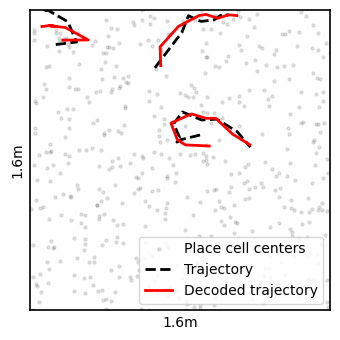

In [6]:
fig, ax = plt.subplots(figsize=(3.5,3.5))
ax.scatter(centers[:, 0], centers[:, 1], s=5, color='black', alpha=0.1, label='Place cell centers')
np.random.seed(17)
for k in range(3):
    ind = np.random.randint(0, len(pred))
    ax.plot(pos[ind, :, 0], pos[ind, :, 1], color='k', label='Trajectory', ls='--', lw=2)
    ax.plot(pred[ind, :, 0], pred[ind, :, 1], color='red', label='Decoded trajectory', ls='-', lw=2)
    if k==0:
        ax.legend()
ax.set_xlim(-0.8, 0.8)
ax.set_ylim(-0.8, 0.8)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('1.6m')
ax.set_ylabel('1.6m')
# show full arena frame
for side in ["top", "right", "bottom", "left"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.2)
plt.tight_layout()
# plt.savefig('../results/task/traj.pdf', bbox_inches='tight')
plt.show()


In [7]:
errors = np.sqrt(((pos - pred) ** 2).sum(axis=-1)).mean(axis=-1)
errors_untrained = np.sqrt(((pos_untrain - pred_untrain) ** 2).sum(axis=-1)).mean(axis=-1)
errors_bs1 = np.sqrt(((pos_bs1 - pred_bs1) ** 2).sum(axis=-1)).mean(axis=-1)


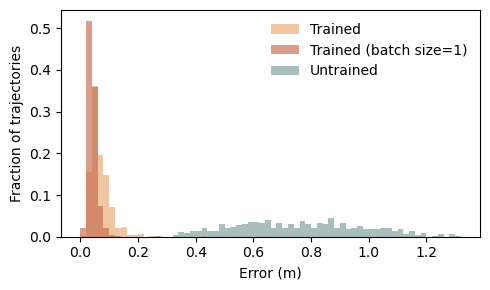

In [8]:
fig, ax = plt.subplots(figsize=(5, 3))
bin_width = 0.02
bins = np.arange(
    0,
    max(errors.max(), errors_untrained.max(), errors_bs1.max()) + bin_width,
    bin_width,
)

ax.hist(
    errors,
    bins=bins,
    color="#e9b383",
    label="Trained",
    weights=np.ones_like(errors) / len(errors),
    alpha=0.75,
)
ax.hist(
    errors_bs1,
    bins=bins,
    color="#c56a4d",
    label="Trained (batch size=1)",
    weights=np.ones_like(errors_bs1) / len(errors_bs1),
    alpha=0.65,
)
ax.hist(
    errors_untrained,
    bins=bins,
    color="#7c9d97",
    label="Untrained",
    weights=np.ones_like(errors_untrained) / len(errors_untrained),
    alpha=0.65,
)

ax.legend(frameon=False)
ax.set_xlabel("Error (m)")
ax.set_ylabel("Fraction of trajectories")
plt.tight_layout()
# plt.savefig("../results/task/errors_with_batch1.pdf", bbox_inches="tight")
plt.show()


In [9]:
mean_error = errors.mean()
mean_error_untrained = errors_untrained.mean()
mean_error_bs1 = errors_bs1.mean()

print(f"Mean error (trained): {mean_error:.4f} m")
print(f"Mean error (untrained): {mean_error_untrained:.4f} m")
print(f"Mean error (trained, batch size=1): {mean_error_bs1:.4f} m")

Mean error (trained): 0.0687 m
Mean error (untrained): 0.7574 m
Mean error (trained, batch size=1): 0.0411 m


## Loss comparison

In [10]:
import pickle
import numpy as np
import os
import matplotlib.pyplot as plt

from src.visualize import *
import src.utils as utils
# from pypalettes import load_cmap

import pandas as pd
import seaborn as sns

In [11]:
w_init = "normal"
save_path = f'../results/task/losses/losses_list_{w_init}.pkl'
load_existing = True  # set True to load, False to save

os.makedirs(os.path.dirname(save_path), exist_ok=True)

if load_existing and os.path.exists(save_path):
    with open(save_path, 'rb') as f:
        losses_list = pickle.load(f)
        tpc_losses, rnn_losses, rnn_prev_losses, \
        rnn_trunc_losses, rnn_trunc_prev_losses, \
        rnn_online_losses, rnn_online_prev_losses = losses_list
else:
    with open(save_path, 'wb') as f:
        losses_list = [tpc_losses, rnn_losses, rnn_prev_losses, \
                       rnn_trunc_losses, rnn_trunc_prev_losses, \
                       rnn_online_losses, rnn_online_prev_losses]
        pickle.dump(losses_list, f)

In [12]:
# Cell-style figure settings
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 9,
    'axes.linewidth': 0.8,
    'axes.edgecolor': 'black',
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'legend.frameon': False
})

# Plotting function for loss curves with mean and standard deviation
def plot_loss_curves(losses_list, labels=None, colors=None, figsize=(3, 2.3), savepath=None):
    fig, ax = plt.subplots(figsize=figsize)

    if labels is None:
        labels = [f"Model {i+1}" for i in range(len(losses_list))]
    if colors is None:
        colors = [f"C{i}" for i in range(len(losses_list))]

    for i, losses in enumerate(losses_list):
        mean_loss = losses.mean(axis=0)
        # Standard deviation across runs/seeds
        if losses.shape[0] > 1:
            std_loss = losses.std(axis=0, ddof=1)
        else:
            std_loss = np.zeros_like(mean_loss)

        x = np.arange(losses.shape[1])
        ax.plot(x, mean_loss, label=labels[i], color=colors[i], lw=1.2)
        ax.fill_between(x, mean_loss - std_loss, mean_loss + std_loss, color=colors[i], alpha=0.3)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, which='major', linestyle='--', alpha=0.2)
    ax.set_xlabel('Training Epoch', fontsize=10)
    ax.set_ylabel('Training Loss', fontsize=10)
    legend = ax.legend(loc='upper right', fontsize=10, ncol=1)
    for line in legend.get_lines():
        line.set_linewidth(2.) 

    plt.tight_layout()
    if savepath is not None:
        plt.savefig(savepath, bbox_inches='tight')
    plt.show()

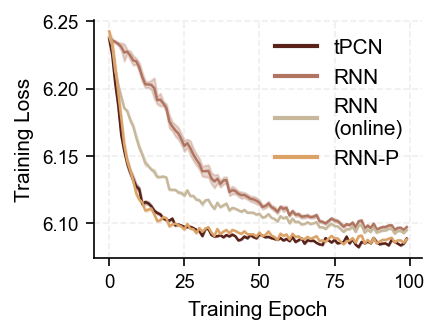

In [13]:
# Without truncation
losses_list = [tpc_losses, rnn_losses, rnn_online_losses, rnn_prev_losses]
labels_list = ['tPCN', 'RNN', 'RNN\n(online)', 'RNN-P']

# # With truncation
# losses_list = [tpc_losses, rnn_trunc_losses, rnn_trunc_prev_losses, rnn_online_losses]
# labels_list = ['tPCN', 'RNN_trunc4', 'RNN_trunc1 (prev)', 'RNN_online']

# Example usage
plot_loss_curves(
    losses_list=losses_list,
    labels=labels_list,
    colors=['#582119', '#B07560', '#C7B89C', '#DBA367'],
    savepath=f'../results/task/loss_comparison_{w_init}.pdf'
)

In [14]:
# larger batch size
tpc_path = 'Apr-10-2025-16-13-23'
rnn_path = 'Apr-28-2025-12-10-16'

loss_tpc = np.load(os.path.join('../results/tpc', tpc_path, 'loss.npy'))
loss_rnn = np.load(os.path.join('../results/rnn', rnn_path, 'loss.npy'))

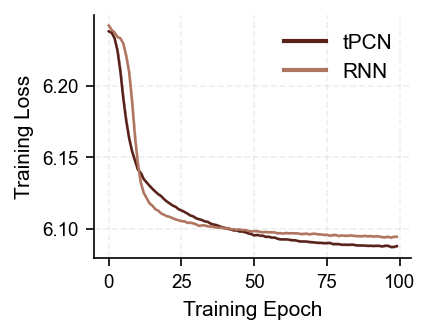

In [15]:
plot_loss_curves(
    losses_list=[loss_tpc[None, :], loss_rnn[None, :]],  # Add a new axis to make it 2D
    labels=['tPCN', 'RNN'],
    colors=['#582119', '#B07560'],
    savepath='../results/task/loss_comparison_default_batched.pdf'
)